# Sentiment Analysis using Naive Bayes Classifier
## Dataset: IMDB Movie Reviews (Keras)

### High-Level Process

1. **Load Data** - Pull the IMDB dataset (25K train + 25K test reviews, binary: positive/negative) from keras
2. **EDA** - Explore class balance, review lengths, and most frequent words.
3. **Feature Extraction** - Decode integer encoded reviews back to text, then apply TF-IDF vectorization
4. **Preprocessing** - Clean text (lowercase, remove punctuation/stopwords, lemmatize), build TF-IDF feature matrix
5. **Model Training** - Fit a Multinomial Naive Bayes classifier on the preprocessed training dataset.
6. **Testing** - Predict on the test set, sanity test on Custom sentences.
7. **Error Analysis** - Confusion matrix, classification report, and inspection of misclassified samples.

In [50]:
# Uncomment and run to install the dependencies if not already installed
#!pip install nltk
#!pip install wordcloud


## 1. Imports & Setup

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.datasets import imdb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import nltk
nltk.download('wordnet', quiet=True)
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# for reproducibility
np.random.seed(42)

## 2. Load IMDB Dataset:

**About the IMDB Dataset from Keras:** 

This is a dataset containing 25,000 movies reviews from IMDB, labeled by sentiment (positive/negative). Reviews have been preprocessed, and each review is encoded as a list of word indexes (integers). For convenience, words are indexed by overall frequency in the dataset, so that for instance the integer "3" encodes the 3rd most frequent word in the data. This allows for quick filtering operations such as: "only consider the top 10,000 most common words, but eliminate the top 20 most common words". 

Reference: https://keras.io/api/datasets/imdb/


For this application, we cap the vocabulary at the top 10,000 words to keep things manageable.


In [52]:
NUM_WORDS = 10000

(x_train_raw, y_train), (x_test_raw, y_test) = imdb.load_data(num_words=NUM_WORDS)

print(f"Training samples : {len(x_train_raw)}")
print(f"Test samples     : {len(x_test_raw)}")
print(f"Labels           : {np.unique(y_train)}  (0 = negative, 1 = positive)")

Training samples : 25000
Test samples     : 25000
Labels           : [0 1]  (0 = negative, 1 = positive)


In [53]:
# The dataset ships with a word-index dictionary; we reverse it to decode integers to words.
# Index offsets reserved in IMDB Dataset: 0=padding, 1=start, 2=unknown — so we shift by 3.
word_index = imdb.get_word_index()
reverse_index = {v + 3: k for k, v in word_index.items()}
# Add the reserved words to the reverse index at 0,1,2
reverse_index.update({0: '<PAD>', 1: '<START>', 2: '<UNK>'})

# Function to convert an encoded sequence (list of integers) back into plain text.
# If the integer is not found, it defaults to '<UNK>'.
def decode_review(encoded):
    return ' '.join(reverse_index.get(i, '<UNK>') for i in encoded)

# Decode all reviews to plain text
x_train_text = [decode_review(r) for r in x_train_raw]
x_test_text  = [decode_review(r) for r in x_test_raw]

print("Sample decoded review:")
print(x_train_text[0][:300], '...')

Sample decoded review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the ...


## 3. Exploratory Data Analysis (EDA)

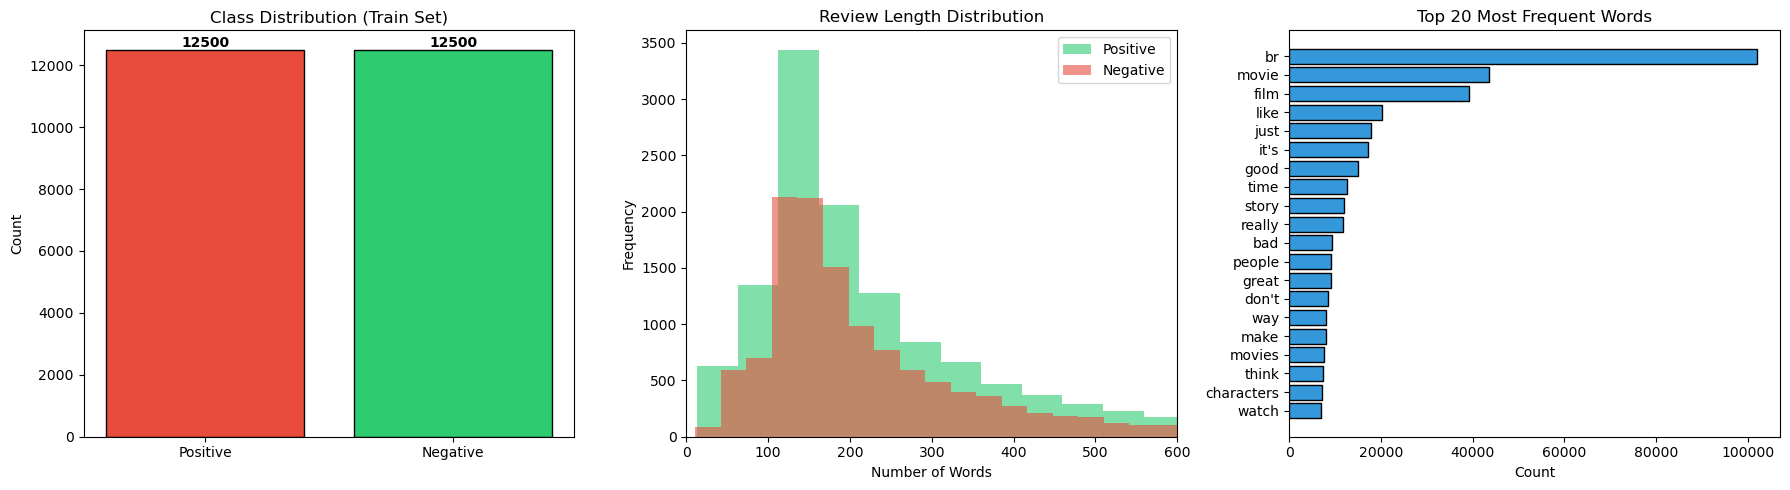

In [54]:
# --- Plot 1: Class Distribution ---
# Checking whether the dataset is balanced between positive and negative reviews
label_counts = pd.Series(y_train).value_counts().rename({0: 'Negative', 1: 'Positive'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(label_counts.index, label_counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution (Train Set)')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# --- Plot 2: Review Length Distribution ---
# Longer reviews might carry more signal; this shows how varied review lengths are
train_lengths = [len(r.split()) for r in x_train_text]
pos_lengths = [l for l, y in zip(train_lengths, y_train) if y == 1]
neg_lengths = [l for l, y in zip(train_lengths, y_train) if y == 0]

axes[1].hist(pos_lengths, bins=50, alpha=0.6, color='#2ecc71', label='Positive')
axes[1].hist(neg_lengths, bins=50, alpha=0.6, color='#e74c3c', label='Negative')
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 600)

# --- Plot 3: Top 20 Most Frequent Words ---
# A quick look at what words dominate the corpus after removing the stopwords)
from collections import Counter # A simmple frequency counter for words
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

all_words = ' '.join(x_train_text).split()
# filter out stopwords and the special tokens added during decoding
filtered = [w for w in all_words if w not in ENGLISH_STOP_WORDS and not w.startswith('<')]
top_words = Counter(filtered).most_common(20)
words, counts = zip(*top_words)

axes[2].barh(words[::-1], counts[::-1], color='#3498db', edgecolor='black')
axes[2].set_title('Top 20 Most Frequent Words')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()

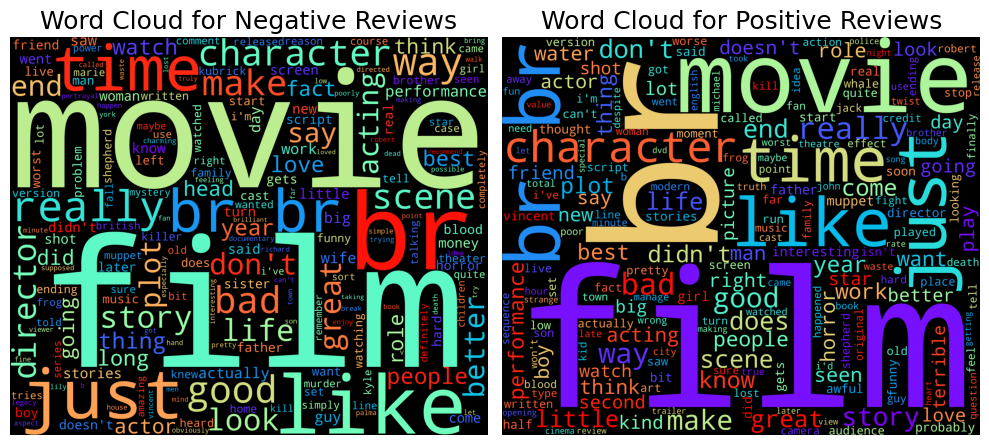

In [55]:
# Lets visualize which words that constitute the most in negative as well as positive reviews using a Word Cloud.
# This is not a very good technique to understand the reviews since most of the negative reviews 
# may contain bi-grams or tri-grams to assess sentiments. Example , "not good", "too slow" etc 
# But is a good starting point to understand the most common words in negative reviews.
from wordcloud import WordCloud
filtered_neg = [w for w, y in zip(all_words, y_train) if y == 0 and w not in ENGLISH_STOP_WORDS and not w.startswith('<')]
filtered_pos = [w for w, y in zip(all_words, y_train) if y == 1 and w not in ENGLISH_STOP_WORDS and not w.startswith('<')]
gen_wc_neg = WordCloud(stopwords=ENGLISH_STOP_WORDS,  #exclude all the stopwords
                   background_color='black',
                   width = 3000,
                   height= 2500,
                   colormap = 'rainbow').generate(' '.join(filtered_neg))

gen_wc_pos = WordCloud(stopwords=ENGLISH_STOP_WORDS,  #exclude all the stopwords
                   background_color='black',
                   width = 3000,
                   height= 2500,
                   colormap = 'rainbow').generate(' '.join(filtered_pos))


# Let us plot the word clouds
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gen_wc_neg)
axes[0].axis('off')
axes[0].set_title('Word Cloud for Negative Reviews', fontsize=18)

axes[1].imshow(gen_wc_pos)
axes[1].axis('off')
axes[1].set_title('Word Cloud for Positive Reviews', fontsize=18)

plt.subplots_adjust(wspace=0.05)   # reduce gap
plt.tight_layout()
plt.savefig('gen_wc.png', dpi=150, bbox_inches='tight')
plt.show()


### Observations:
1. Words like Movie, Film, br etc are common in Negative and Positive reviews.
2. Some opposite words are noticed Example, "good" in negative reviews and "bad" in positive reviews
suggesting bi-grams (not good, not bad etc) used in reviews should get considered. 

In [56]:
# Quick summary stats on review lengths
length_df = pd.DataFrame({'length': train_lengths, 'sentiment': ['Positive' if y == 1 else 'Negative' for y in y_train]})
print(length_df.groupby('sentiment')['length'].describe().round(1))

             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
Negative   12500.0  235.9  169.4  11.0  131.0  179.0  284.0  1571.0
Positive   12500.0  241.6  183.2  13.0  128.0  178.0  297.0  2494.0


## 4. Text Preprocessing & Feature Extraction

We clean the decoded text and convert it into a TF-IDF matrix.
TF-IDF (Term Frequency–Inverse Document Frequency) weights words by how
informative they are across the corpus - a good fit for Naive Bayes.

In [57]:
# Function to clean reviews
def clean_text(text):
    # drop the special tokens the decoder added, then strip non-alpha characters
    text = re.sub(r'<[^>]+>', ' ', text)   # remove <PAD>, <START>, <UNK>
    text = re.sub(r'[^a-z\s]', ' ', text.lower())
    text = re.sub(r'\s+', ' ', text).strip()
    # lemmatize each word to reduce inflected forms to their base (e.g. 'running' -> 'run')
    text = ' '.join(lemmatizer.lemmatize(w) for w in text.split())
    return text

x_train_clean = [clean_text(r) for r in x_train_text]
x_test_clean  = [clean_text(r) for r in x_test_text]

print("Before:", x_train_text[0][:150])
print("After :", x_train_clean[0][:150])

Before: <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine
After : this film wa just brilliant casting location scenery story direction everyone s really suited the part they played and you could just imagine being th


### TF-IDF vs Count vectorization

**Count Vectorization:** Counts how many times each word appears in a document.
- Frequent words dominate

    
**TF-IDF:** Calculates TF*IDF score to check the importance of a word. 

- Penalizes most frequently used words across all the documents. 
- Highlights sentiment bearing words.     
- Example: "terrible" or "excellent" get higher weights because they carry sentiments and not uniformly distributed.


For this example, we selected TF-IDF over Count Vectorization for training the model for the following reasons:

1. As seen in the Word Cloud plot, Words like "film", "movie" etc are common in positive and negative reviews alike in the dataset. With CountVectorizer, these words will dominate the feature space but carry zero sentiment signal.
2.  IDF component naturally suppresses these corpus-wide common words and highlights sentiment bearing words. 


In [58]:
# TF-IDF vectorization
# - max_features: keep only the 20K most informative terms
# - ngram_range (1,2): include both single words and two-word phrases (bigrams)
# - sublinear_tf: apply log scaling to term frequencies to reduce the impact of very common words
# - stop_words: drop English stopwords since they carry little sentiment signal
# - Note that Sklearn's TfidfVectorizer removes stop words implicitly here so we dont have to explicitly remove them before-hand.
# - TfidfVectorizer also handles bigrams correctly. For example, for "not good" if we had removed "not" as a stop word, we would lose the sentiment signal entirely.
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english'
)

# fit only on training data to avoid data leakage
X_train = tfidf.fit_transform(x_train_clean)
X_test  = tfidf.transform(x_test_clean)

print(f"Training feature matrix : {X_train.shape}")
print(f"Test feature matrix     : {X_test.shape}")

Training feature matrix : (25000, 20000)
Test feature matrix     : (25000, 20000)


## 5. Train Naive Bayes Classifier

We use **Multinomial Naive Bayes** - a good choice for text classification
with TF-IDF. 

In [59]:
# alpha is the Laplace smoothing parameter — prevents zero probabilities
# for words that appear in test but not in training
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)

print("Model trained successfully.")
print(f"Classes: {nb_model.classes_}  -->  0 = Negative, 1=Positive")

Model trained successfully.
Classes: [0 1]  -->  0 = Negative, 1=Positive


## 6. Test the Model

In [60]:
y_pred = nb_model.predict(X_test)
y_pred_proba = nb_model.predict_proba(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Test Accuracy: 0.8564


In [61]:
# Quick sanity check — predict sentiment on a couple of custom sentences
custom_reviews = [
    "This movie was absolutely fantastic! Great acting and a brilliant story.",
    "Terrible film. Boring plot, bad acting, complete waste of time."
]
custom_clean = [clean_text(r) for r in custom_reviews]
custom_vec   = tfidf.transform(custom_clean)
custom_preds = nb_model.predict(custom_vec)

for review, pred in zip(custom_reviews, custom_preds):
    label = 'POSITIVE 😊' if pred == 1 else 'NEGATIVE 😞'
    print(f"{label}: {review[:60]}...")

POSITIVE 😊: This movie was absolutely fantastic! Great acting and a bril...
NEGATIVE 😞: Terrible film. Boring plot, bad acting, complete waste of ti...


## 7. Performance Evaluation & Error Analysis

In [62]:
# Full classification report — precision, recall, F1 per class
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.85      0.87      0.86     12500
    Positive       0.86      0.85      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



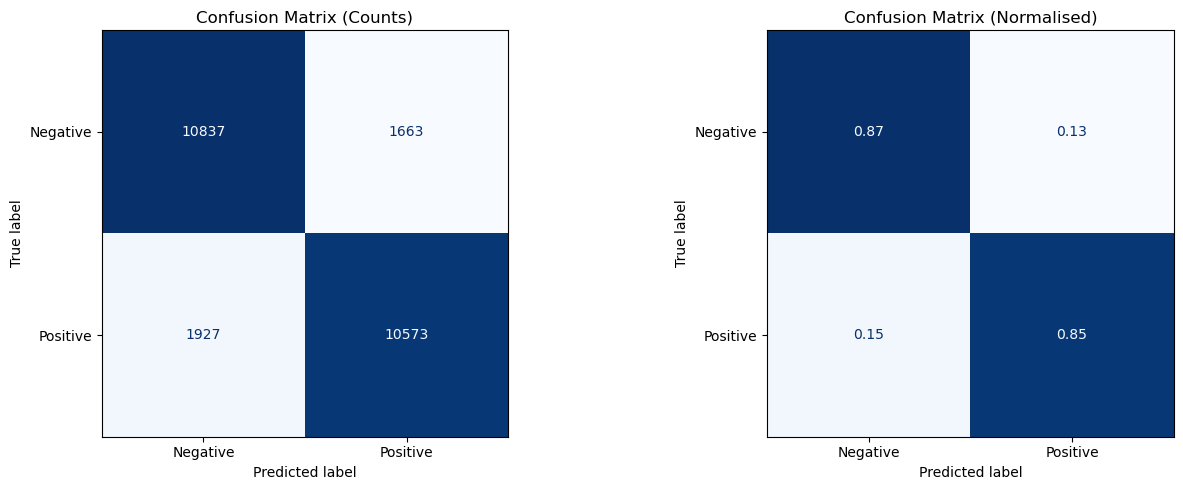

In [63]:
# Confusion matrix — shows where the model is getting confused
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw counts
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)')

# normalised — easier to compare when classes are balanced
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(cm_norm.round(3), display_labels=['Negative', 'Positive'])
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (Normalised)')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# Error Analysis: Lets inpect some misclassified reviews - helps understand model limitations.
errors_df = pd.DataFrame({
    'review'    : x_test_clean,
    'true_label': y_test,
    'pred_label': y_pred,
    'confidence': y_pred_proba.max(axis=1)   # how confident the model was
})

misclassified = errors_df[errors_df['true_label'] != errors_df['pred_label']]
print(f"Total misclassified: {len(misclassified)} / {len(errors_df)} ({len(misclassified)/len(errors_df)*100:.1f}%)")
print(f"\nFalse Positives (predicted Positive, actually Negative): {((y_pred==1) & (y_test==0)).sum()}")
print(f"False Negatives (predicted Negative, actually Positive): {((y_pred==0) & (y_test==1)).sum()}")

Total misclassified: 3590 / 25000 (14.4%)

False Positives (predicted Positive, actually Negative): 1663
False Negatives (predicted Negative, actually Positive): 1927


In [65]:
# -------------- Analyse High Confidence mistakes --------------
# Lets take a look at some High-confidence mistakes.
# Which the model was very sure but still got it wrong.
high_conf_errors = misclassified.sort_values('confidence', ascending=False).head(5)

print("=== Top 5 High-Confidence Misclassifications ===")
for _, row in high_conf_errors.iterrows():
    true_lbl = 'Positive' if row['true_label'] == 1 else 'Negative'
    pred_lbl = 'Positive' if row['pred_label'] == 1 else 'Negative'
    print(f"\nTrue: {true_lbl} | Predicted: {pred_lbl} | Confidence: {row['confidence']:.3f}")
    print(row['review'][:200], '...')

=== Top 5 High-Confidence Misclassifications ===

True: Positive | Predicted: Negative | Confidence: 0.988
yes indeed we have a winner a winner in best dumb action movie br br the only reason i chose to vote a for this movie is because it s so incredibly bad made that it actually becomes funny br br night  ...

True: Positive | Predicted: Negative | Confidence: 0.988
spoiler ahead br br it is really unfortunate that a movie so well produced turn out to be br br such a disappointment i thought this wa full of silly clich s and br br that it basically tried to hard  ...

True: Negative | Predicted: Positive | Confidence: 0.982
the kissing wa the third and final film that frank sinatra and kathryn grayson co starred at mgm with the first two were anchor aweigh and it happened in brooklyn and in both sinatra and lost grayson  ...

True: Positive | Predicted: Negative | Confidence: 0.981
do it yourself indie horror auteur todd sheet return with another atrocious shot on video that s basical

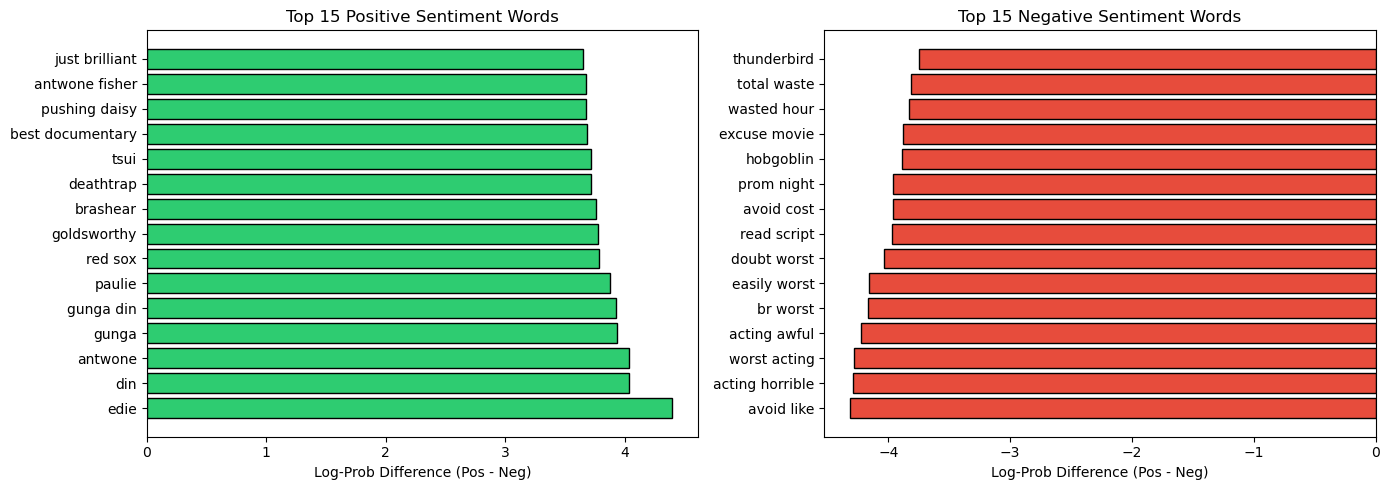

In [66]:
# -------------- Analyse Top discriminative features per class --------------
# Words that most strongly push the model toward a particular sentiment
feature_names = np.array(tfidf.get_feature_names_out())
log_probs = nb_model.feature_log_prob_   # shape: (2, n_features)

# For each word, calculate thedifference in log-probability between positive and negative class.
# diff > 0 means the word is more likely in + reviews, diff < 0 means it's more likely in - reviews
diff = log_probs[1] - log_probs[0]
# top 15 words with the largest positive differences
top_positive = feature_names[np.argsort(diff)[-15:][::-1]]
# top 15 words with the largest negative differences
top_negative = feature_names[np.argsort(diff)[:15]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(15), np.sort(diff)[-15:][::-1], color='#2ecc71', edgecolor='black')
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(top_positive)
axes[0].set_title('Top 15 Positive Sentiment Words')
axes[0].set_xlabel('Log-Prob Difference (Pos - Neg)')

axes[1].barh(range(15), np.sort(diff)[:15], color='#e74c3c', edgecolor='black')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top_negative)
axes[1].set_title('Top 15 Negative Sentiment Words')
axes[1].set_xlabel('Log-Prob Difference (Pos - Neg)')

plt.tight_layout()
plt.savefig('discriminative_features.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Summary

Naive Bayes coupled with TF-IDF is a strong solution for implementing Sentiment Analysis. In terms of Model performance, we got ~85%+ in all the evaluation related metrics on the IMDB dataset as highlighted in the below model summary: 

In [67]:
# Final summary
tn, fp, fn, tp = cm.ravel()
print("=== Final Model Summary ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {tp / (tp + fp):.4f}  (of all predicted positive, how many were actually positive)")
print(f"Recall    : {tp / (tp + fn):.4f}  (of all actual positives, how many did we catch)")
print(f"F1 Score  : {2*tp / (2*tp + fp + fn):.4f}")


=== Final Model Summary ===
Accuracy  : 0.8564
Precision : 0.8641  (of all predicted positive, how many were actually positive)
Recall    : 0.8458  (of all actual positives, how many did we catch)
F1 Score  : 0.8549
